# Model Comparison

Compare all four brain tumor classification models on the shared test split (`brain_tumor_split_seed123.csv`):

1. Baseline Custom CNN (`baseline_custom_cnn.keras`)
2. Deeper Custom CNN (`model2_deeper_cnn.keras`)
3. VGG16 transfer learning (metrics loaded from `model3_results/vgg16_final_metrics.json`)
4. EfficientNetB0 transfer learning (metrics loaded from `outputs/efficientnet_b0/<run>/experiment_summary.json`)

Models 1 and 2 are re-evaluated here on the shared test set. Models 3 and 4 do not have a saved `.keras` checkpoint in this workspace, so their previously saved evaluation results are reused instead.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.22.0-rc0


## 1. Load the shared dataset split

Use the same CSV manifest used by every model so the comparison is fair.

In [2]:
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

data_dir = project_dir / "data"
manifest_path = project_dir / "splits" / "brain_tumor_split_seed123.csv"

manifest_df = pd.read_csv(manifest_path)

class_names = ["glioma", "meningioma", "notumor", "pituitary"]

test_df = manifest_df[manifest_df["split"] == "test"].copy()

print("Testing images:", len(test_df))
print("Classes:", class_names)

Testing images: 1584
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## 2. Build the shared test dataset

Both custom CNNs (Model 1 and Model 2) were trained on 224x224 images with pixel
values in the 0-255 range, and each model has its own `Rescaling` layer. The same
preprocessing is used here so the saved models can be evaluated directly.

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32


def load_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)
    return image, label


def make_dataset(dataframe):
    paths = [
        str(data_dir / relative_path)
        for relative_path in dataframe["relative_path"]
    ]
    labels = dataframe["class_id"].to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


# Test order is kept fixed, so predictions line up with test_df rows.
test_ds = make_dataset(test_df)
y_true = test_df["class_id"].to_numpy(dtype="int32")

images, labels = next(iter(test_ds))
print("Image batch shape:", images.shape)

Image batch shape: (32, 224, 224, 3)


## 3. Evaluate Model 1 (Baseline CNN) and Model 2 (Deeper CNN)

Load each saved `.keras` file and evaluate it on the shared test set.

In [4]:
def evaluate_saved_model(model_path, model_name):
    model = tf.keras.models.load_model(str(model_path))

    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

    probabilities = model.predict(test_ds, verbose=0)
    predicted_labels = np.argmax(probabilities, axis=1)

    report = classification_report(
        y_true,
        predicted_labels,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    summary = {
        "model": model_name,
        "test_accuracy": float(test_accuracy),
        "test_loss": float(test_loss),
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
    }

    return summary, predicted_labels


baseline_path = project_dir / "notebooks" / "baseline_custom_cnn.keras"
deeper_path = project_dir / "notebooks" / "model2_deeper_cnn.keras"

results = []
predictions_by_model = {}

baseline_summary, baseline_preds = evaluate_saved_model(
    baseline_path, "Baseline Custom CNN"
)
results.append(baseline_summary)
predictions_by_model["Baseline Custom CNN"] = baseline_preds

deeper_summary, deeper_preds = evaluate_saved_model(
    deeper_path, "Deeper Custom CNN"
)
results.append(deeper_summary)
predictions_by_model["Deeper Custom CNN"] = deeper_preds

for summary in (baseline_summary, deeper_summary):
    print(summary["model"], "-> accuracy:", round(summary["test_accuracy"], 4))

Baseline Custom CNN -> accuracy: 0.8908
Deeper Custom CNN -> accuracy: 0.8346


## 4. Load saved results for Model 3 (VGG16) and Model 4 (EfficientNetB0)

No `.keras` checkpoint is available in this workspace for these two models, so their
previously computed evaluation metrics are reused instead of retraining or re-predicting.

In [5]:
# --- Model 3: VGG16 ---
vgg16_metrics_path = project_dir / "notebooks" / "model3_results" / "vgg16_final_metrics.json"

if vgg16_metrics_path.is_file():
    with vgg16_metrics_path.open(encoding="utf-8") as file:
        vgg16_metrics = json.load(file)

    results.append({
        "model": "VGG16",
        "test_accuracy": vgg16_metrics.get("test_accuracy"),
        "test_loss": vgg16_metrics.get("test_loss"),
        "macro_precision": np.nan,
        "macro_recall": np.nan,
        "macro_f1": vgg16_metrics.get("macro_f1"),
        "weighted_f1": vgg16_metrics.get("weighted_f1"),
    })
    print("Loaded VGG16 metrics from:", vgg16_metrics_path)
else:
    print("VGG16 metrics not found at:", vgg16_metrics_path)

# --- Model 4: EfficientNetB0 ---
efficientnet_runs_dir = project_dir / "outputs" / "efficientnet_b0"
run_dirs = sorted(d for d in efficientnet_runs_dir.iterdir() if d.is_dir())

if run_dirs:
    latest_run_dir = run_dirs[-1]
    effnet_summary_path = latest_run_dir / "experiment_summary.json"

    with effnet_summary_path.open(encoding="utf-8") as file:
        effnet_summary = json.load(file)

    test_results = effnet_summary["test_results"]

    results.append({
        "model": "EfficientNetB0",
        "test_accuracy": test_results.get("accuracy"),
        "test_loss": test_results.get("loss"),
        "macro_precision": test_results.get("macro_precision"),
        "macro_recall": test_results.get("macro_recall"),
        "macro_f1": test_results.get("macro_f1"),
        "weighted_f1": test_results.get("weighted_f1"),
    })
    print("Loaded EfficientNetB0 metrics from:", effnet_summary_path)
else:
    print("No EfficientNetB0 run folders found in:", efficientnet_runs_dir)

Loaded VGG16 metrics from: c:\projects\SE4050-Deep-Learning-Assignment\notebooks\model3_results\vgg16_final_metrics.json
Loaded EfficientNetB0 metrics from: c:\projects\SE4050-Deep-Learning-Assignment\outputs\efficientnet_b0\20260927_202528\experiment_summary.json


## 5. Combine results into a single comparison table

In [6]:
comparison_df = pd.DataFrame(results).set_index("model")
comparison_df = comparison_df.round(4)

display(comparison_df)

output_path = project_dir / "outputs" / "model_comparison_summary.csv"
comparison_df.to_csv(output_path)
print("Comparison table saved to:", output_path)

,test_accuracy,test_loss,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,,
Baseline Custom CNN,0.8908,0.9908,0.8955,0.8895,0.8885,0.8890
Deeper Custom CNN,0.8346,1.5440,0.8430,0.8340,0.8350,0.8352
VGG16,0.9003,0.4710,NaN,NaN,0.8978,0.8985
EfficientNetB0,0.8952,0.3606,0.9000,0.8937,0.8922,0.8930


Comparison table saved to: c:\projects\SE4050-Deep-Learning-Assignment\outputs\model_comparison_summary.csv


## 6. Visualize test accuracy and macro F1 across models

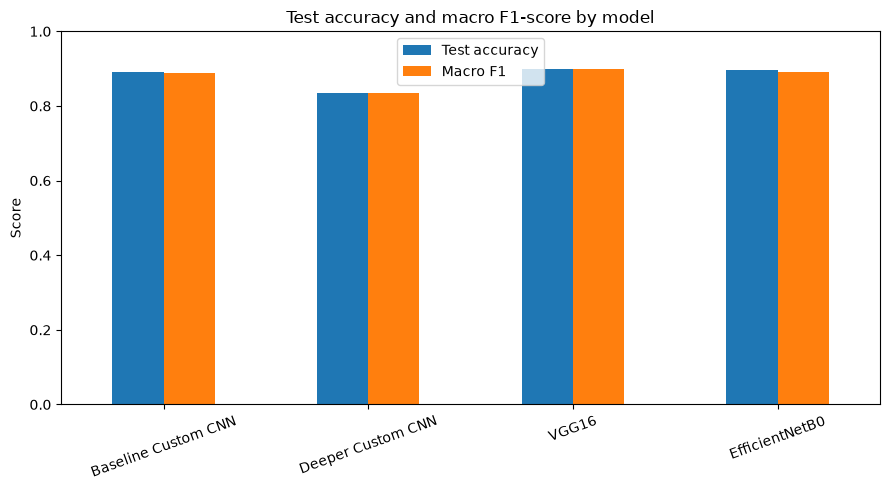

Chart saved to: c:\projects\SE4050-Deep-Learning-Assignment\outputs\model_comparison_chart.png


In [7]:
plot_df = comparison_df[["test_accuracy", "macro_f1"]].reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
plot_df.plot(
    x="model",
    y=["test_accuracy", "macro_f1"],
    kind="bar",
    ax=ax,
)

ax.set_title("Test accuracy and macro F1-score by model")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(["Test accuracy", "Macro F1"])
plt.xticks(rotation=20)
plt.tight_layout()

figure_path = project_dir / "outputs" / "model_comparison_chart.png"
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Chart saved to:", figure_path)

## 7. Confusion matrices for the freshly evaluated models

Model 3 (VGG16) and Model 4 (EfficientNetB0) already have confusion matrix images
saved from their own notebooks (`model3_results/vgg16_confusion_matrix.png` and
`outputs/efficientnet_b0/<run>/test_confusion_matrix.png`).

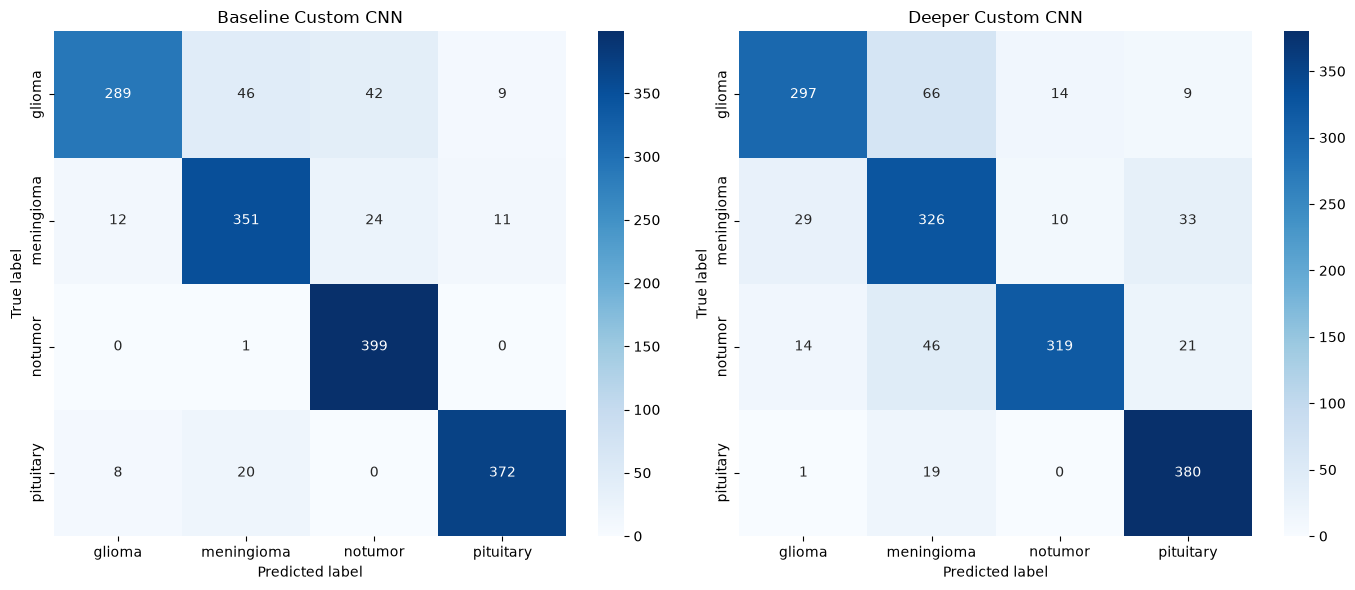

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in zip(axes, ["Baseline Custom CNN", "Deeper Custom CNN"]):
    predicted_labels = predictions_by_model[model_name]
    cm = confusion_matrix(y_true, predicted_labels)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.tight_layout()
plt.show()

## 8. Conclusion

Re-run this notebook after re-training any model to refresh `outputs/model_comparison_summary.csv`
and `outputs/model_comparison_chart.png`. The final ranking should be read from the printed
comparison table above rather than hard-coded here, since results depend on the currently
saved checkpoints and JSON summaries.